In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Set plotting style
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams['figure.figsize'] = (14, 6)

import warnings
warnings.filterwarnings('ignore')

In [4]:
# Assuming you have a fused or raw dataset ready
FILE_PATH = "../data/interim/urbanev_fused.csv" # Update path as needed
df = pd.read_csv(FILE_PATH)

print("--- Dataset Shape ---")
print(df.shape)

df.head()

--- Dataset Shape ---
(1194600, 9)


,timestamp,zone_id,charge_count,occupancy,occ_ratio,volume,duration,s_price,e_price
0,2022-09-01 00:00:00,102,30,17.0,0.566667,56.291667,8.833333,0.856,0.924
1,2022-09-01 01:00:00,102,30,16.0,0.533333,50.458333,8.166667,0.856,0.924
2,2022-09-01 02:00:00,102,30,16.0,0.533333,55.708333,8.916667,0.856,0.924
3,2022-09-01 03:00:00,102,30,16.0,0.533333,57.750000,9.166667,0.856,0.924
4,2022-09-01 04:00:00,102,30,17.0,0.566667,58.333333,9.250000,0.856,0.924


## DataSet Overview

In [5]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194600 entries, 0 to 1194599
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   timestamp     1194600 non-null  object 
 1   zone_id       1194600 non-null  int64  
 2   charge_count  1194600 non-null  int64  
 3   occupancy     1194600 non-null  float64
 4   occ_ratio     1194600 non-null  float64
 5   volume        1194600 non-null  float64
 6   duration      1194600 non-null  float64
 7   s_price       1194600 non-null  float64
 8   e_price       1194600 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 82.0+ MB


In [9]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract temporal features
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek # 0=Monday, 6=Sunday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)
df['month'] = df['timestamp'].dt.month

# Check for missing values
print("--- Missing Values ---")
display(df.isnull().sum())

--- Missing Values ---


timestamp       0
zone_id         0
charge_count    0
occupancy       0
occ_ratio       0
volume          0
duration        0
s_price         0
e_price         0
hour            0
day_of_week     0
is_weekend      0
month           0
dtype: int64

In [15]:
for col in df.columns:
    print(col, ":", df[col].nunique())

timestamp : 4344
zone_id : 275
charge_count : 123
occupancy : 309
occ_ratio : 4330
volume : 59653
duration : 6063
s_price : 1722
e_price : 1121
hour : 24
day_of_week : 7
is_weekend : 2
month : 6


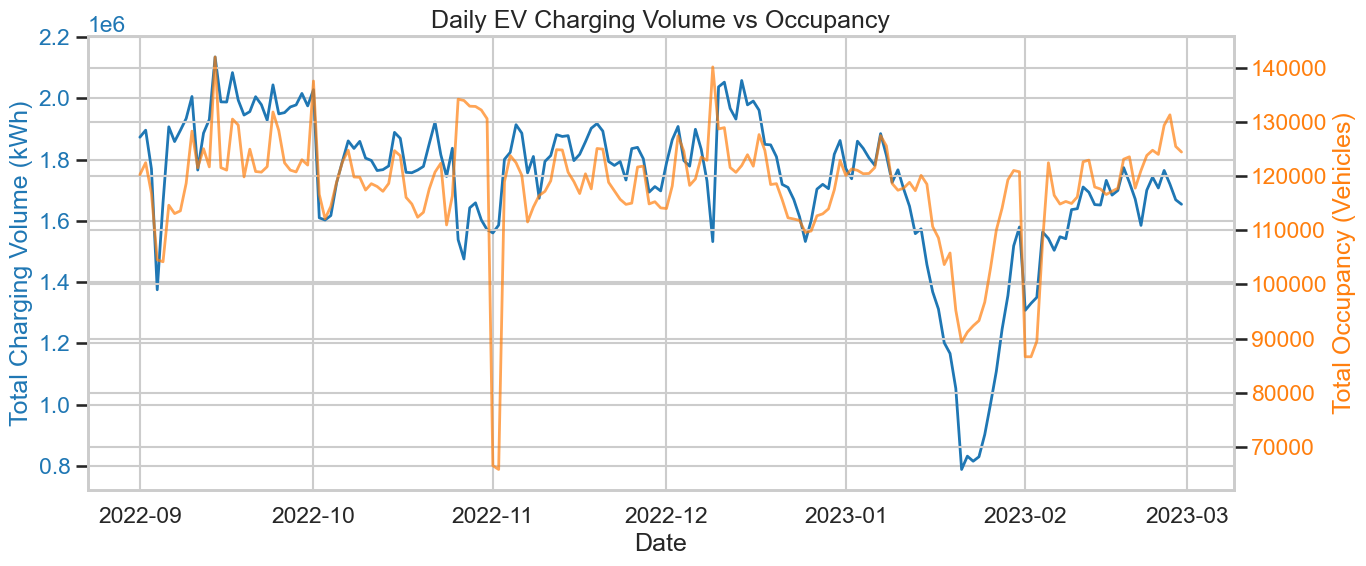

In [10]:
# Aggregate data daily
daily_trends = df.groupby(df['timestamp'].dt.date)[['volume', 'occupancy']].sum().reset_index()
daily_trends['timestamp'] = pd.to_datetime(daily_trends['timestamp'])

fig, ax1 = plt.subplots()

# Plot Total Volume
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Charging Volume (kWh)', color=color)
ax1.plot(daily_trends['timestamp'], daily_trends['volume'], color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Create a twin axis for Total Occupancy
ax2 = ax1.twinx()  
color = 'tab:orange'
ax2.set_ylabel('Total Occupancy (Vehicles)', color=color)  
ax2.plot(daily_trends['timestamp'], daily_trends['occupancy'], color=color, linewidth=2, alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Daily EV Charging Volume vs Occupancy')
fig.tight_layout()  
plt.show()

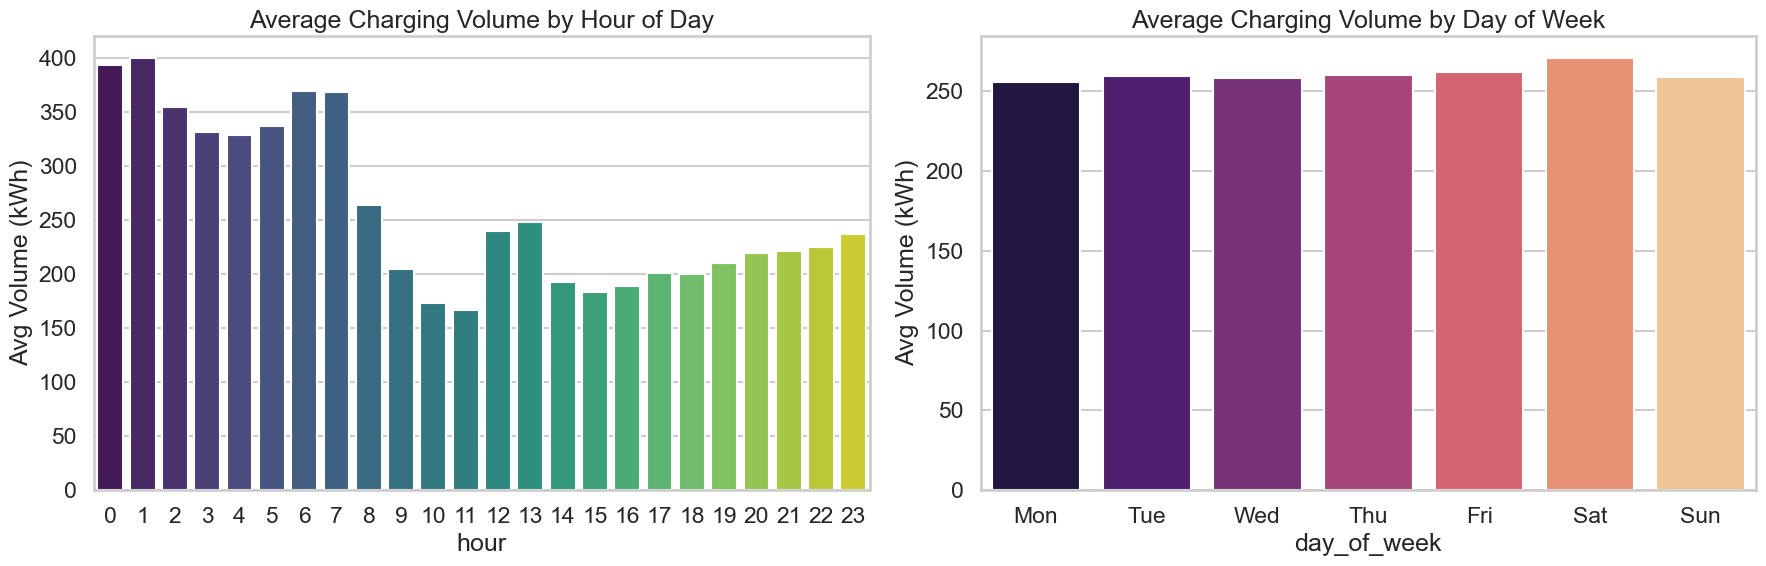

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Hourly Trend
hourly_avg = df.groupby('hour')['volume'].mean().reset_index()
sns.barplot(data=hourly_avg, x='hour', y='volume', ax=axes[0], palette="viridis")
axes[0].set_title('Average Charging Volume by Hour of Day')
axes[0].set_ylabel('Avg Volume (kWh)')

# Day of Week Trend
dow_avg = df.groupby('day_of_week')['volume'].mean().reset_index()
sns.barplot(data=dow_avg, x='day_of_week', y='volume', ax=axes[1], palette="magma")
axes[1].set_title('Average Charging Volume by Day of Week')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel('Avg Volume (kWh)')

plt.tight_layout()
plt.show()

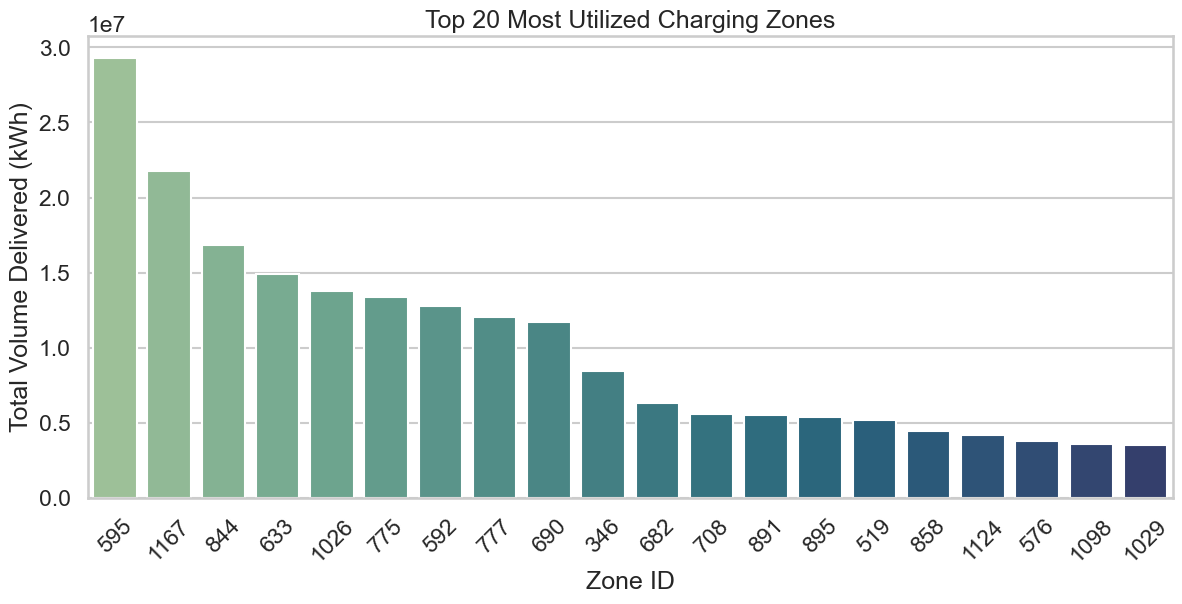

In [12]:
# Calculate total volume per zone
zone_volume = df.groupby('zone_id')['volume'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(14, 6))
# Plot top 20 zones to avoid clutter
sns.barplot(data=zone_volume.head(20), x='zone_id', y='volume', order=zone_volume.head(20)['zone_id'], palette="crest")
plt.title('Top 20 Most Utilized Charging Zones')
plt.xlabel('Zone ID')
plt.ylabel('Total Volume Delivered (kWh)')
plt.xticks(rotation=45)
plt.show()

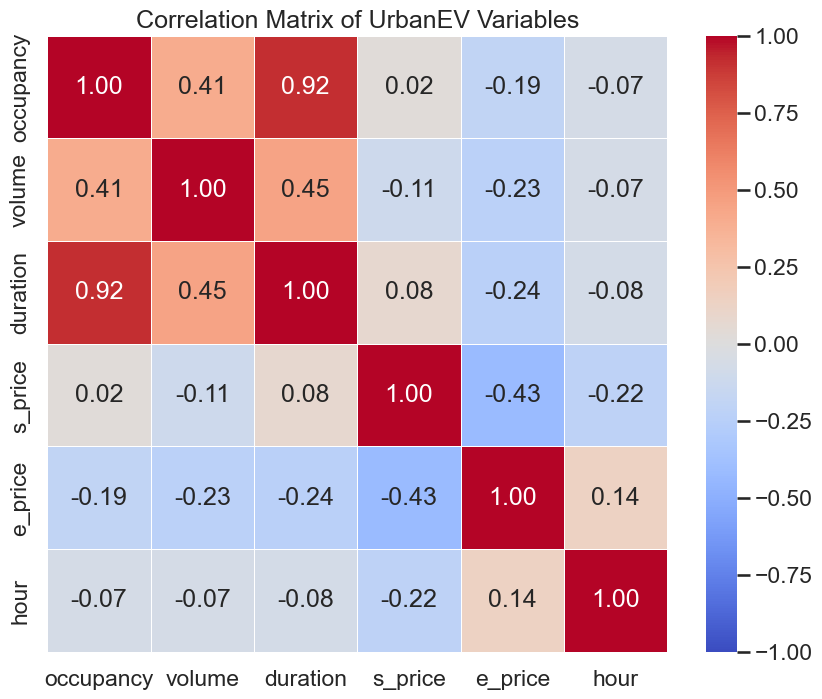

In [13]:
# Select numeric columns for correlation
cols_to_correlate = ['occupancy', 'volume', 'duration', 's_price', 'e_price', 'hour']
# Filter out columns that might not exist in your specific dataframe
cols_to_correlate = [c for c in cols_to_correlate if c in df.columns]

corr_matrix = df[cols_to_correlate].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of UrbanEV Variables')
plt.show()